# AI Romantic Relationship Simulator — Results

This notebook answers three questions:
1. **Do different personalities make different choices?**
2. **Do those choices produce different outcomes?**
3. **Does your *partner's* personality matter as much as your own?**

Run all cells top to bottom. Make sure you have a trained checkpoint at `data/checkpoints/latest.pt`.

In [1]:
import sys
import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from collections import Counter

sys.path.insert(0, str(Path(".").resolve()))  # run from project root

from src.env.marriage_env import MarriageEnv
from src.agents.agent import Agent
from src.env.events import ACTION_NAMES
from src.env.state import _TRAIT_NAMES, X_DIM

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

CONFIG = "config/default.yaml"
EVENTS = "config/events.yaml"
CKPT   = "data/checkpoints/latest.pt"

with open(CONFIG) as f:
    cfg = yaml.safe_load(f)

env        = MarriageEnv(CONFIG, EVENTS)
obs_dim    = env.observation_space.shape[0]
hidden_dim = cfg["training"]["hidden_dim"]
device     = torch.device("cpu")

agent_h = Agent(obs_dim, 5, hidden_dim, lr=1e-3, device=device, x_dim=X_DIM)
agent_w = Agent(obs_dim, 5, hidden_dim, lr=1e-3, device=device, x_dim=X_DIM)

ckpt = torch.load(CKPT, map_location="cpu", weights_only=False)
agent_h.policy.load_state_dict(ckpt["agent_h_policy"])
agent_h.value.load_state_dict(ckpt["agent_h_value"])
agent_w.policy.load_state_dict(ckpt["agent_w_policy"])
agent_w.value.load_state_dict(ckpt["agent_w_value"])
agent_h.policy.eval()
agent_w.policy.eval()

print(f"Checkpoint loaded — episode {ckpt['episode']}")
print(f"obs_dim={obs_dim}  hidden_dim={hidden_dim}")

Checkpoint loaded — episode 10000
obs_dim=45  hidden_dim=128


In [2]:
# ── Archetypes & palette ───────────────────────────────────────────────────────

ARCHETYPES = {
    "emotional": dict(
        eq=0.9, emotional_reasoning=0.9, ability_to_love=0.9,
        iq=0.4, rational_thinking=0.1, kindness=0.8,
        faithfulness=0.7, responsibility=0.5, mental_stability=0.5,
    ),
    "rational": dict(
        iq=0.9, rational_thinking=0.9, eq=0.4,
        emotional_reasoning=0.1, ability_to_love=0.4,
        kindness=0.5, faithfulness=0.7, responsibility=0.8, mental_stability=0.7,
    ),
    "avoidant": dict(
        mental_stability=0.2, eq=0.2, ability_to_love=0.2,
        emotional_reasoning=0.2, kindness=0.3,
        iq=0.5, rational_thinking=0.5, faithfulness=0.4, responsibility=0.3,
    ),
    "secure": dict(
        mental_stability=0.9, faithfulness=0.9, kindness=0.9,
        eq=0.85, ability_to_love=0.85, emotional_reasoning=0.75,
        iq=0.65, rational_thinking=0.65, responsibility=0.85,
    ),
}

ARCH_NAMES   = list(ARCHETYPES.keys())
ARCH_COLORS  = {"emotional": "#E8694C", "rational": "#4C9BE8",
                "avoidant": "#B07FD4",  "secure": "#8DC87A"}
ACTION_COLORS = ["#4C9BE8", "#E8694C", "#8DC87A", "#F5C842", "#B07FD4"]

def _inject(traits_h, traits_w):
    """Inject fixed traits into env after a reset."""
    for side, traits in [(env.x_h, traits_h), (env.x_w, traits_w)]:
        for attr, val in traits.items():
            setattr(side, attr, float(val))
        side.innate = np.array([traits.get(t, 0.5) for t in _TRAIT_NAMES], dtype=np.float32)


def run_pair(arch_h, arch_w, n_episodes=50, seed=0):
    """
    Run n_episodes with both agents locked to fixed archetype traits.
    Returns a list of episode records containing outcomes, action frequencies,
    and the full Y-state trajectory.
    """
    np.random.seed(seed)
    th, tw = ARCHETYPES[arch_h], ARCHETYPES[arch_w]
    records = []

    for _ in range(n_episodes):
        env.reset()
        _inject(th, tw)
        obs_h = env._get_obs("h")
        obs_w = env._get_obs("w")

        acts_h = []
        traj   = {k: [] for k in ["happiness", "stability", "love_support", "pressure", "trust_h", "resentment_h"]}
        done   = False

        while not done:
            ah, _, _ = agent_h.act(obs_h)
            aw, _, _ = agent_w.act(obs_w)
            obs_h, _, done, _, info = env.step([ah, aw])
            obs_w = info["obs_w"]
            acts_h.append(ah)
            yh = info["y_state_h"]  # [wealth, love_support, pressure, happiness, stability, trust, resentment]
            yw = info["y_state_w"]
            traj["love_support"].append((yh[1] + yw[1]) / 2)
            traj["pressure"].append((yh[2] + yw[2]) / 2)
            traj["happiness"].append((yh[3] + yw[3]) / 2)
            traj["stability"].append((yh[4] + yw[4]) / 2)
            traj["trust_h"].append(yh[5])
            traj["resentment_h"].append(yh[6])

        n = len(acts_h)
        records.append({
            "happiness":    traj["happiness"][-1],
            "stability":    traj["stability"][-1],
            "love_support": traj["love_support"][-1],
            "pressure":     traj["pressure"][-1],
            "trust_h":      traj["trust_h"][-1],
            "resentment_h": traj["resentment_h"][-1],
            "action_dist":  [acts_h.count(i) / n for i in range(5)],
            "trajectory":   {k: np.array(v) for k, v in traj.items()},
        })

    return records

print("Helpers ready.")

Helpers ready.


---
## 1 — What does each personality choose?

We lock both agents to the same archetype and run 50 episodes.
The bar chart shows how often each personality reaches for each action.

**What to look for:** emotional agents should lean on `support`, rational agents on `compromise`, avoidant agents on `ignore`/`withdraw`, secure agents on a healthy mix of `support` + `compromise`.

In [3]:
print("Running self-paired episodes (this takes ~30s)...")
self_pairs = {arch: run_pair(arch, arch, n_episodes=50) for arch in ARCH_NAMES}
print("Done.")

Running self-paired episodes (this takes ~30s)...
Done.


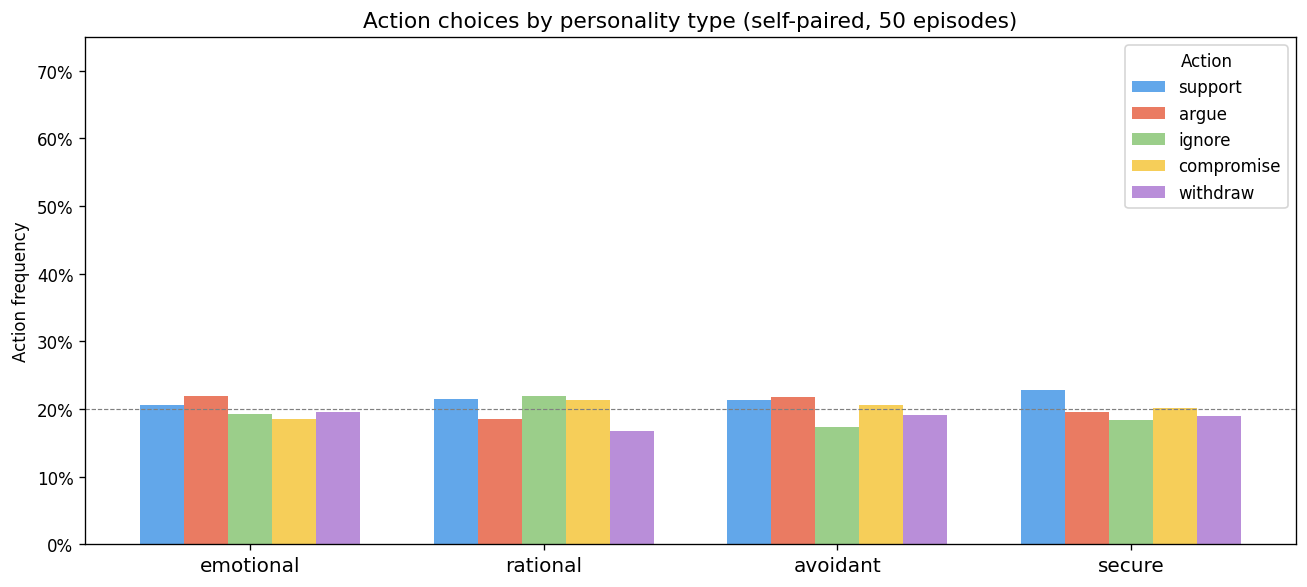

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))

x     = np.arange(len(ARCH_NAMES))
width = 0.15

for i, (action, color) in enumerate(zip(ACTION_NAMES, ACTION_COLORS)):
    vals = [
        np.mean([r["action_dist"][i] for r in self_pairs[arch]])
        for arch in ARCH_NAMES
    ]
    ax.bar(x + i * width, vals, width, label=action, color=color, alpha=0.88)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(ARCH_NAMES, fontsize=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 0.75)
ax.set_ylabel("Action frequency")
ax.set_title("Action choices by personality type (self-paired, 50 episodes)", fontsize=13)
ax.legend(title="Action", loc="upper right")
ax.axhline(0.20, color="grey", linewidth=0.7, linestyle="--", label="random baseline")

plt.tight_layout()
plt.savefig("data/1_action_distributions.png", dpi=120)
plt.show()

---
## 2 — What outcomes does each personality produce?

Same episodes, now we look at the final Y-state values.

**What to look for:**
- **Emotional** — highest `love_support`, but potentially unstable under pressure
- **Rational** — highest `stability`, but lower emotional warmth
- **Avoidant** — low across the board; disengagement erodes the relationship
- **Secure** — best overall; balanced warmth and stability

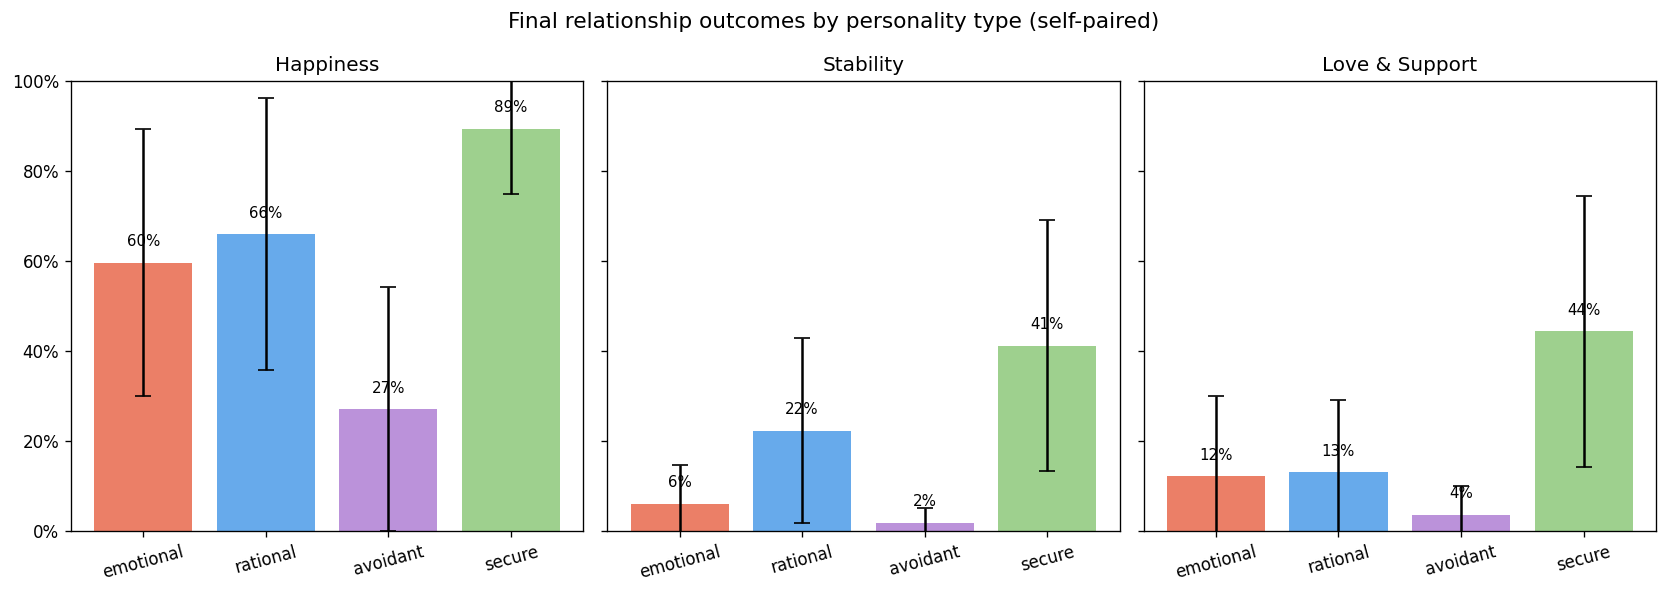

In [5]:
METRICS      = ["happiness", "stability", "love_support"]
METRIC_LABEL = ["Happiness", "Stability", "Love & Support"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
fig.suptitle("Final relationship outcomes by personality type (self-paired)", fontsize=13)

for ax, metric, label in zip(axes, METRICS, METRIC_LABEL):
    means = [np.mean([r[metric] for r in self_pairs[arch]]) for arch in ARCH_NAMES]
    stds  = [np.std( [r[metric] for r in self_pairs[arch]]) for arch in ARCH_NAMES]
    colors = [ARCH_COLORS[a] for a in ARCH_NAMES]

    bars = ax.bar(ARCH_NAMES, means, yerr=stds, capsize=5,
                  color=colors, alpha=0.85, error_kw={"linewidth": 1.5})
    ax.set_ylim(0, 1)
    ax.set_title(label, fontsize=12)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.tick_params(axis="x", rotation=15)

    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, mean + 0.03,
                f"{mean:.0%}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("data/2_outcomes_by_archetype.png", dpi=120)
plt.show()

---
## 3 — Does your partner's personality matter?

We run all 4 × 4 = 16 archetype combinations and plot three outcome heatmaps.
Rows = husband's archetype, columns = wife's archetype.

**What to look for:**
- The diagonal (same-type pairs) isn't always the best
- Emotional + rational may be *complementary* — one brings warmth, the other brings structure
- Avoidant + avoidant should be the worst cell in every heatmap
- Secure pairs best with almost anyone

In [6]:
print("Running all 16 archetype pair combinations (this takes ~2 min)...")

pair_results = {}
for ah in ARCH_NAMES:
    for aw in ARCH_NAMES:
        pair_results[(ah, aw)] = run_pair(ah, aw, n_episodes=40)
        print(f"  {ah} + {aw} done")

print("Done.")

Running all 16 archetype pair combinations (this takes ~2 min)...
  emotional + emotional done
  emotional + rational done
  emotional + avoidant done
  emotional + secure done
  rational + emotional done
  rational + rational done
  rational + avoidant done
  rational + secure done
  avoidant + emotional done
  avoidant + rational done
  avoidant + avoidant done
  avoidant + secure done
  secure + emotional done
  secure + rational done
  secure + avoidant done
  secure + secure done
Done.


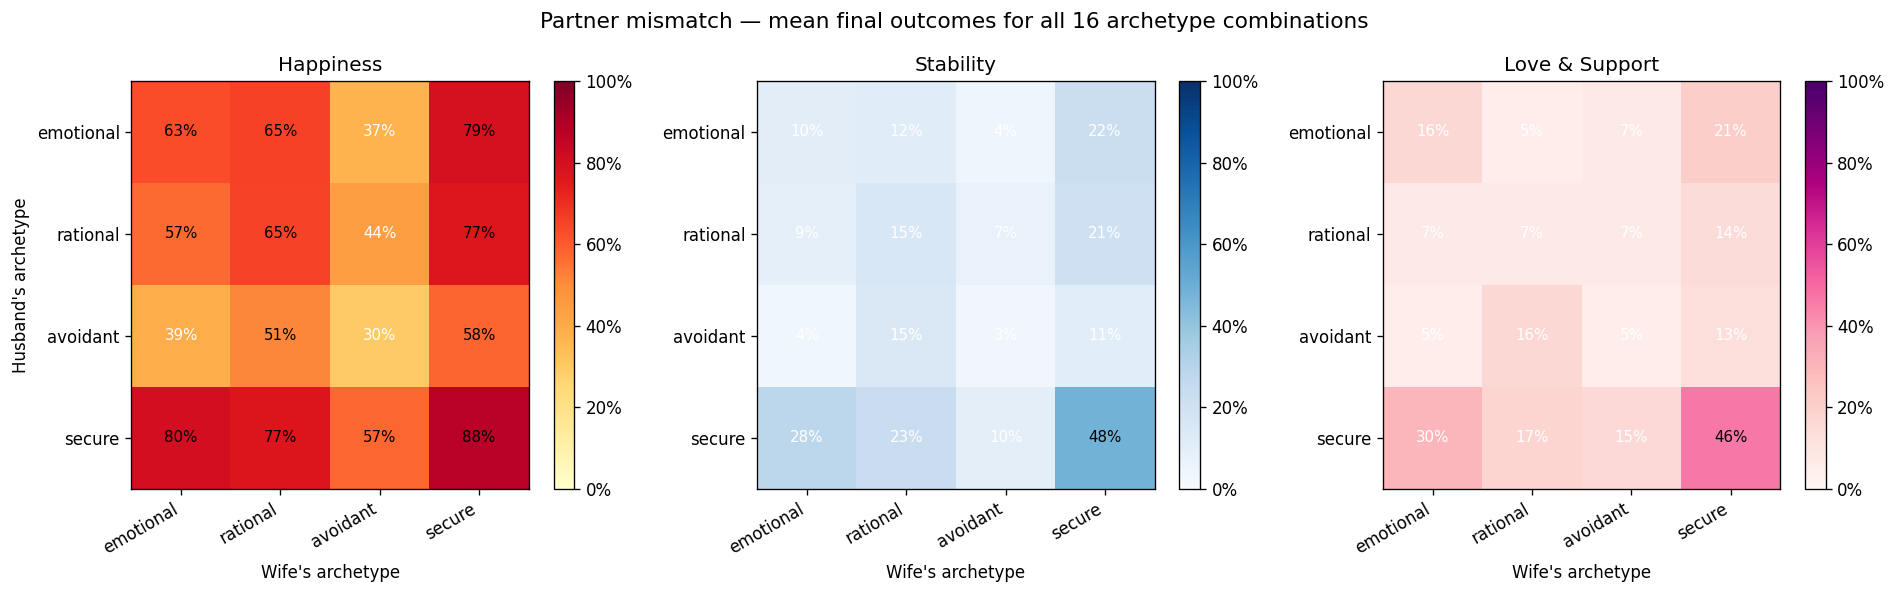

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Partner mismatch — mean final outcomes for all 16 archetype combinations",
             fontsize=13)

cmaps = ["YlOrRd", "Blues", "RdPu"]

for ax, metric, label, cmap in zip(axes, METRICS, METRIC_LABEL, cmaps):
    matrix = np.zeros((len(ARCH_NAMES), len(ARCH_NAMES)))
    for i, ah in enumerate(ARCH_NAMES):
        for j, aw in enumerate(ARCH_NAMES):
            matrix[i, j] = np.mean([r[metric] for r in pair_results[(ah, aw)]])

    im = ax.imshow(matrix, vmin=0, vmax=1, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(ARCH_NAMES)))
    ax.set_yticks(range(len(ARCH_NAMES)))
    ax.set_xticklabels(ARCH_NAMES, rotation=30, ha="right", fontsize=10)
    ax.set_yticklabels(ARCH_NAMES, fontsize=10)
    ax.set_xlabel("Wife's archetype")
    if ax is axes[0]:
        ax.set_ylabel("Husband's archetype")
    ax.set_title(label, fontsize=12)
    plt.colorbar(im, ax=ax, format=mticker.PercentFormatter(xmax=1))

    for i in range(len(ARCH_NAMES)):
        for j in range(len(ARCH_NAMES)):
            ax.text(j, i, f"{matrix[i,j]:.0%}",
                    ha="center", va="center", fontsize=9,
                    color="white" if matrix[i, j] < 0.45 else "black")

plt.tight_layout()
plt.savefig("data/3_partner_mismatch_heatmaps.png", dpi=120)
plt.show()

---
## 4 — The trade-off: warmth vs stability

Every archetype pair lands somewhere on the love_support ↔ stability spectrum.
This scatter shows whether those two goods can be achieved simultaneously,
or whether every personality profile has to sacrifice one for the other.

**What to look for:** a top-right cluster (high warmth *and* high stability) is the ideal.
Avoidant pairs should land bottom-left. The interesting question is where emotional and rational pairs sit relative to each other.

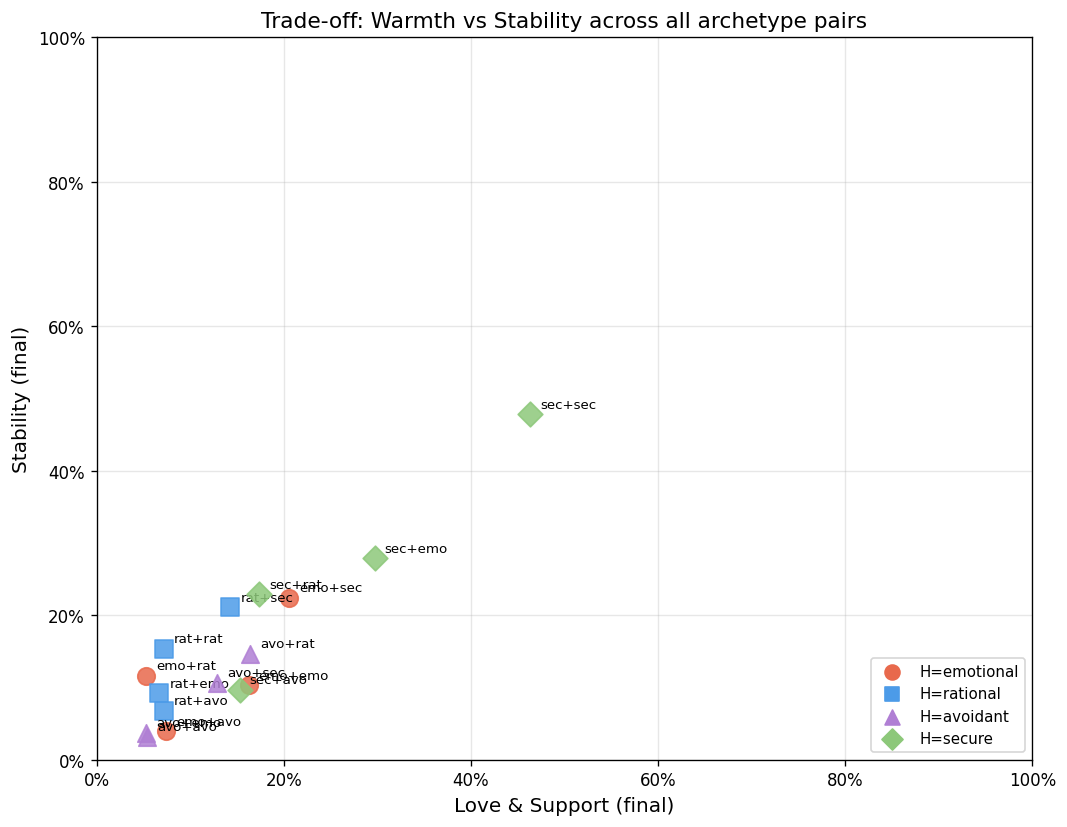

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))

for ah in ARCH_NAMES:
    for aw in ARCH_NAMES:
        recs = pair_results[(ah, aw)]
        x_val = np.mean([r["love_support"] for r in recs])
        y_val = np.mean([r["stability"]    for r in recs])
        color = ARCH_COLORS[ah]
        marker = {"emotional": "o", "rational": "s",
                  "avoidant":  "^", "secure":   "D"}[ah]
        ax.scatter(x_val, y_val, color=color, marker=marker,
                   s=110, alpha=0.85, zorder=3)
        label = f"{ah[:3]}+{aw[:3]}"
        ax.annotate(label, (x_val, y_val),
                    textcoords="offset points", xytext=(6, 4), fontsize=8)

# Legend for H archetype
for arch in ARCH_NAMES:
    m = {"emotional": "o", "rational": "s", "avoidant": "^", "secure": "D"}[arch]
    ax.scatter([], [], color=ARCH_COLORS[arch], marker=m, label=f"H={arch}", s=80)

ax.set_xlabel("Love & Support (final)", fontsize=12)
ax.set_ylabel("Stability (final)", fontsize=12)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title("Trade-off: Warmth vs Stability across all archetype pairs", fontsize=13)
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("data/4_warmth_vs_stability.png", dpi=120)
plt.show()

---
## 5 — What does a marriage look like over time?

We trace the mean Y-state trajectory (averaged over 30 episodes) for five
selected pair combinations. This shows *how* outcomes diverge, not just *where* they end up.

**What to look for:**
- Avoidant pairs should show a slow, steady decline
- Secure pairs should stay high and stable
- Emotional + rational may show an interesting crossover: high warmth early, then levelling off

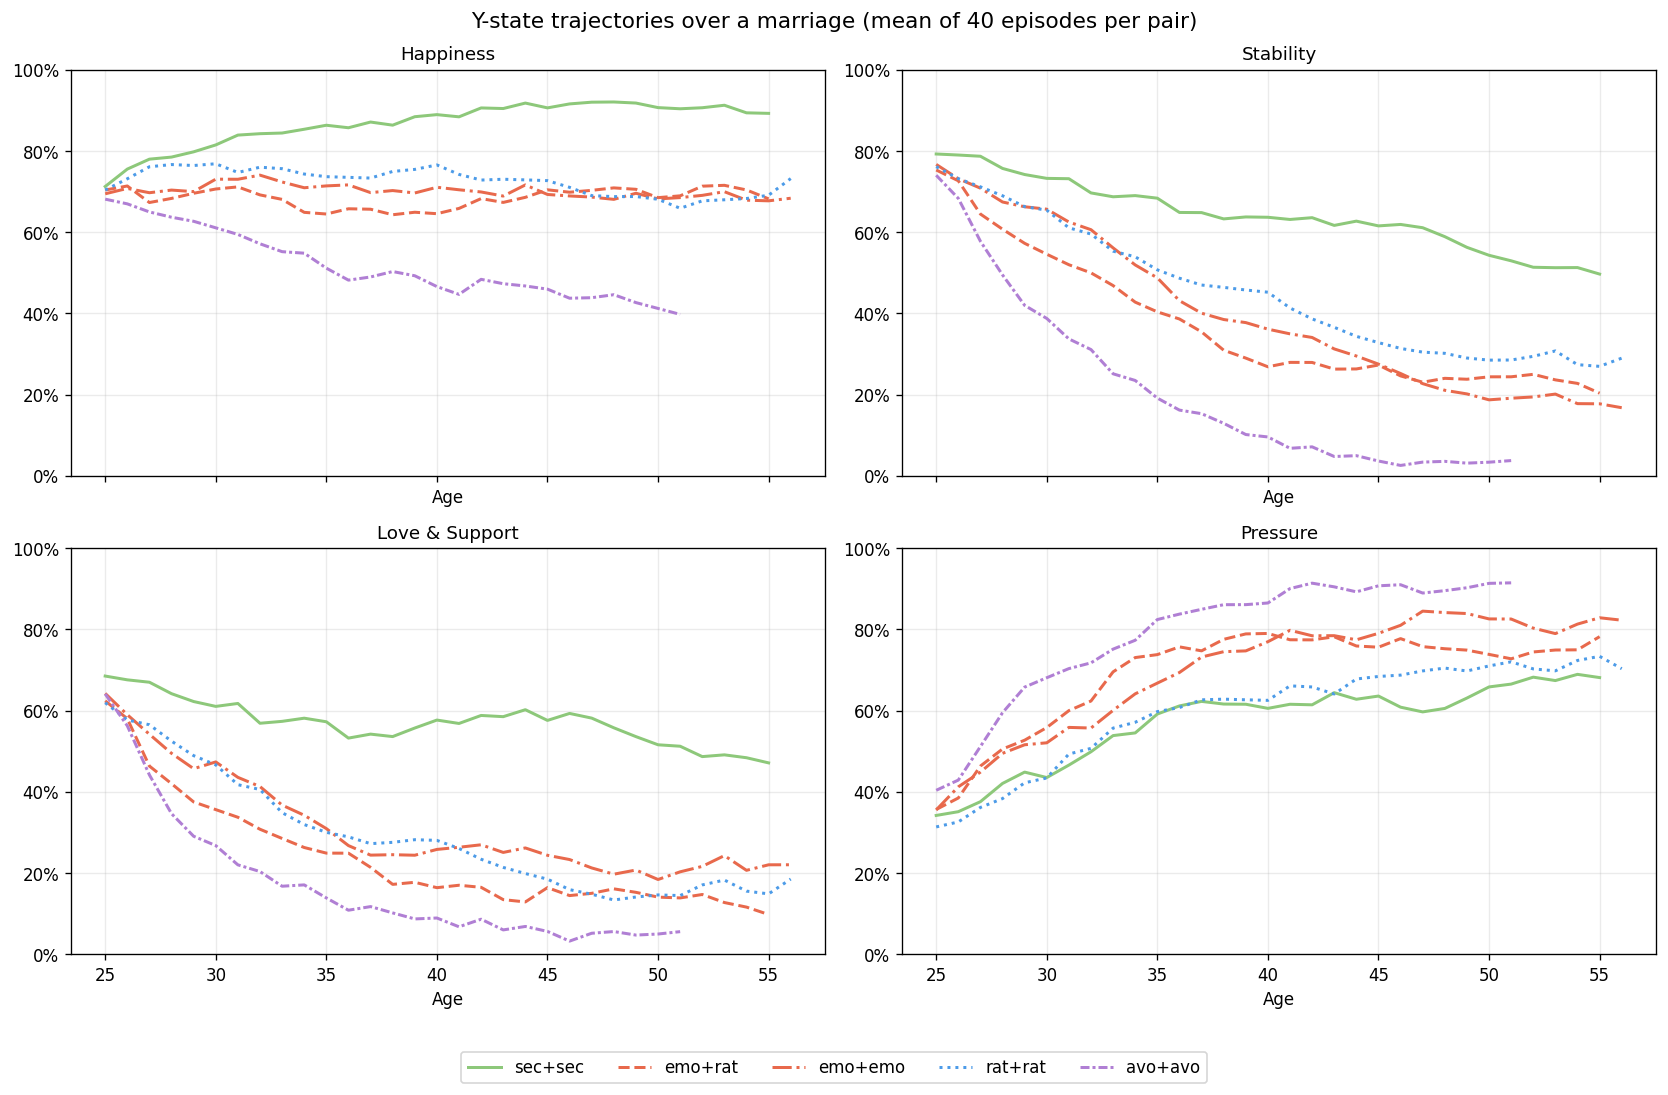

In [9]:
SELECTED_PAIRS = [
    ("secure",    "secure"),
    ("emotional", "rational"),
    ("emotional", "emotional"),
    ("rational",  "rational"),
    ("avoidant",  "avoidant"),
]
PAIR_STYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
TRAJ_METRICS = ["happiness", "stability", "love_support", "pressure"]
TRAJ_LABELS  = ["Happiness", "Stability", "Love & Support", "Pressure"]

# Use already-computed pair_results; average trajectories across episodes
def mean_traj(ah, aw, metric):
    trajs = [r["trajectory"][metric] for r in pair_results[(ah, aw)]]
    min_len = min(len(t) for t in trajs)
    return np.mean([t[:min_len] for t in trajs], axis=0)

ages = np.arange(env.age_start, env.age_end)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
fig.suptitle("Y-state trajectories over a marriage (mean of 40 episodes per pair)",
             fontsize=13)

for ax, metric, label in zip(axes.flat, TRAJ_METRICS, TRAJ_LABELS):
    for (ah, aw), style in zip(SELECTED_PAIRS, PAIR_STYLES):
        traj = mean_traj(ah, aw, metric)
        pair_label = f"{ah[:3]}+{aw[:3]}"
        color = ARCH_COLORS[ah]
        ax.plot(ages[:len(traj)], traj, linestyle=style,
                color=color, linewidth=1.8, label=pair_label)
    ax.set_ylim(0, 1)
    ax.set_title(label, fontsize=11)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_xlabel("Age")
    ax.grid(True, alpha=0.25)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(SELECTED_PAIRS),
           fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("data/5_trajectories.png", dpi=120, bbox_inches="tight")
plt.show()

---
## Summary

| Chart | File | What it shows |
|---|---|---|
| 1 | `data/1_action_distributions.png` | Each personality picks different actions |
| 2 | `data/2_outcomes_by_archetype.png` | Those choices produce different outcomes |
| 3 | `data/3_partner_mismatch_heatmaps.png` | Partner combination matters as much as individual type |
| 4 | `data/4_warmth_vs_stability.png` | The warmth ↔ stability trade-off across all pairs |
| 5 | `data/5_trajectories.png` | How relationships evolve over a lifetime |

All images are saved to `data/` so you can embed them in a report or presentation.